Under the Black-Scholes hedging argument we now that the FD PDE is given by:
$$ \partial_t C_d(t,x) + 0.5 \sigma^2s^2\partial_{ss}C_d(t,s)+rs\partial_sC_d(t,s) - r C_d(t,s) = 0,
$$
with the terminal condition
$$ C_d(T,s) = 1\{s \geq K\}.
$$

Now we will find the solution under this PDE, under the risk-neutral pricing we know that
$$
C_d(t, x) = e^{-r(T-t)}\mathbb{E}^{\mathcal{Q}}[1_{S_T \geq K}|S_t = x],
$$
expectation of an indicator function equals the probability so,
$$
C_d(t, x) = e^{-r(T-t)}\mathbb{Q}(S_T \geq K|S_t=x).
$$
As seen in the lecture the price process $S_t$ can be rewritten by taking the log, and applying Ito's lemma to;
$$
ln(S_T) = ln(S_t)+(r-0.5\sigma^2)(T-t) + \sigma(B_T-B_t)
$$
Note that $\sigma(B_T-B_t) \sim N(0, \sigma^2(T-t))$ since $B_t$ is a brownian motion. So
$$
ln(S_T) \sim N(ln(S_t)+(r-0.5\sigma^2)(T-t), \sigma^2(T-t)).
$$
Denote $\mu = ln(S_t)+(r-0.5\sigma^2)(T-t) $ and define $Z= \frac{ln(S_t)-\mu}{\sigma(\sqrt{T-t})},$ so $Z\sim N(0,1).$

Know we can rewrite $C_d(t,x)$ using the log transformation into
$$
C_d(t, x) = e^{-r(T-t)}\mathbb{Q}(ln(S_T) \geq ln(K)|S_t=x)
$$
which equals
$$
C_d(t, x) = e^{-r(T-t)}\mathbb{Q}(Z\geq \frac{ln(K)-\mu}{\sigma(\sqrt{T-t})} )
$$
which we can, using the earlier found distribution, rewrite into the desired form,
$$
C_d(t,x) = e^{-r(T-t)}\Phi(\frac{ln(x/K)+(r-\sigma^2/2)(T-t)}{|\sigma|\sqrt{T-t}})
$$

### Monte Carlo

Now we will use Monte Carlo to validate this analytical approach that we have done

In [ ]:
import numpy as np

def calc__discounted_payof(Z, S0, r, sigma, T, K):
    discount = np.exp(-r*T)
    ST = S0 * np.exp((r-0.5*sigma**2)*T+sigma*np.sqrt(T)*Z)
    if ST > K:
        return discount
    else: return 0

payoffs = []
S0 = 1.0
K = 1.0
r = 0.05
sigma = 0.2
T = 1.0
N = 100000
for i in range(N):
    Z = np.random.normal(0,1)
    payoff = calc__discounted_payof(Z, S0, r, sigma, T, K)
    payoffs.append(payoff)
mc_price = np.mean(payoffs)
mc_se = np.std(payoffs, ddof=1) / np.sqrt(N)

print("Monte Carlo price:", mc_price)
print("Standard error   :", mc_se)
print("95% CI           :", (mc_price - 1.96 * mc_se, mc_price + 1.96 * mc_se))


Monte Carlo price: 0.5325743301894598
Standard error   : 0.001493208579218196
95% CI           : (np.float64(0.5296476413741921), np.float64(0.5355010190047275))


In [3]:
from math import log
from scipy.stats import norm

def digital_call_closed_form(S0, K, r, sigma, T):
    d_minus = (np.log(S0 / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return np.exp(-r * T) * norm.cdf(d_minus)

cf_price = digital_call_closed_form(S0, K, r, sigma, T)

print("Closed-form price:", cf_price)
print("MC error         :", abs(mc_price - cf_price))

Closed-form price: 0.5323248154537634
MC error         : 0.0002495147356963434


## Solve numerically
Now we will solve our found PDE numerically, remember our PDE was given by,
$$
 \partial_t C_d(t,x) + 0.5 \sigma^2s^2\partial_{ss}C_d(t,s)+rs\partial_sC_d(t,s) - r C_d(t,s) = 0.
$$

In [ ]:
import matplotlib.pyplot as plt

def implicit_digital_call(K, r, sigma, T, S_max, M, N):
    # Grid
    dS = S_max / M
    dt = T / N

    S = np.linspace(0, S_max, M + 1)
    t = np.linspace(0, T, N + 1)

    # Solution array: V[i, n] = option value at S_i, t_n
    V = np.zeros((M + 1, N + 1))

    # Terminal condition
    V[:, -1] = (S >= K).astype(float)

    # Boundary conditions
    V[0, :] = 0.0
    V[-1, :] = np.exp(-r * (T - t))

    # Step backward in time
    for n in range(N - 1, -1, -1):
        A = np.zeros((M - 1, M - 1))
        rhs = V[1:M, n + 1].copy()

        for i in range(1, M):
            Si = S[i]

            a = 0.5 * dt * (sigma**2 * Si**2 / dS**2 - r * Si / dS)
            b = 1.0 + dt * (sigma**2 * Si**2 / dS**2 + r)
            c = 0.5 * dt * (sigma**2 * Si**2 / dS**2 + r * Si / dS)

            row = i - 1

            if i > 1:
                A[row, row - 1] = -a
            A[row, row] = b
            if i < M - 1:
                A[row, row + 1] = -c

        # Add boundary contributions
        # first interior point uses V_0^n
        i = 1
        S1 = S[i]
        a1 = 0.5 * dt * (sigma**2 * S1**2 / dS**2 - r * S1 / dS)
        rhs[0] += a1 * V[0, n]

        # last interior point uses V_M^n
        i = M - 1
        SM1 = S[i]
        cM1 = 0.5 * dt * (sigma**2 * SM1**2 / dS**2 + r * SM1 / dS)
        rhs[-1] += cM1 * V[M, n]

        # Solve tridiagonal system
        V[1:M, n] = np.linalg.solve(A, rhs)

    return S, t, V

K = 1.0
r = 0.05
sigma = 0.2
T = 1.0
S_max = 3.0
M = 200
N = 200

S, t, V = implicit_digital_call(K, r, sigma, T, S_max, M, N)
S0 = 1.0
price_implicit = np.interp(S0, S, V[:, 0])
print("Implicit scheme price:", price_implicit)

Implicit scheme price: 0.5369096736670814


In [12]:
def crank_nicolson_digital(K, r, sigma, T, S_max, M, N):
    dS = S_max / M
    dt = T / N

    S = np.linspace(0, S_max, M + 1)
    t = np.linspace(0, T, N + 1)

    V = np.zeros((M + 1, N + 1))

    # Terminal condition
    V[:, -1] = (S >= K).astype(float)

    # Boundary conditions
    V[0, :] = 0.0
    V[-1, :] = np.exp(-r * (T - t))

    # Build A and B
    A = np.zeros((M - 1, M - 1))
    B = np.zeros((M - 1, M - 1))

    for i in range(1, M):
        Si = S[i]

        alpha = 0.5 * sigma**2 * Si**2 / dS**2
        beta  = 0.5 * r * Si / dS

        # L V_i = (alpha-beta)V_{i-1} + (-2alpha-r)V_i + (alpha+beta)V_{i+1}
        L_im1 = alpha - beta
        L_i   = -2.0 * alpha - r
        L_ip1 = alpha + beta

        row = i - 1

        # A = I - dt/2 * L
        if i > 1:
            A[row, row - 1] = -0.5 * dt * L_im1
        A[row, row] = 1.0 - 0.5 * dt * L_i
        if i < M - 1:
            A[row, row + 1] = -0.5 * dt * L_ip1

        # B = I + dt/2 * L
        if i > 1:
            B[row, row - 1] = 0.5 * dt * L_im1
        B[row, row] = 1.0 + 0.5 * dt * L_i
        if i < M - 1:
            B[row, row + 1] = 0.5 * dt * L_ip1

    # Backward in time
    for n in range(N - 1, -1, -1):
        rhs = B @ V[1:M, n + 1]

        # Boundary corrections
        # Left boundary at i=1
        i = 1
        S1 = S[i]
        alpha1 = 0.5 * sigma**2 * S1**2 / dS**2
        beta1  = 0.5 * r * S1 / dS
        L1_im1 = alpha1 - beta1

        rhs[0] += 0.5 * dt * L1_im1 * (V[0, n] + V[0, n + 1])

        # Right boundary at i=M-1
        i = M - 1
        SM1 = S[i]
        alphaM1 = 0.5 * sigma**2 * SM1**2 / dS**2
        betaM1  = 0.5 * r * SM1 / dS
        LM1_ip1 = alphaM1 + betaM1

        rhs[-1] += 0.5 * dt * LM1_ip1 * (V[M, n] + V[M, n + 1])

        V[1:M, n] = np.linalg.solve(A, rhs)

    return S, t, V


K = 1.0
r = 0.05
sigma = 0.2
T = 1.0
S_max = 3.0
M = 200
N = 200

S, t, V_cn = crank_nicolson_digital(K, r, sigma, T, S_max, M, N)

# Price at S0
S0 = 1.0
price_cn = np.interp(S0, S, V_cn[:, 0])
print("Crank-Nicolson price:", price_cn)

Crank-Nicolson price: 0.5369399196190264


Using these two schemes we will perform a sensitivity analysis. We will be focussing on the volatiliy and strike price. 

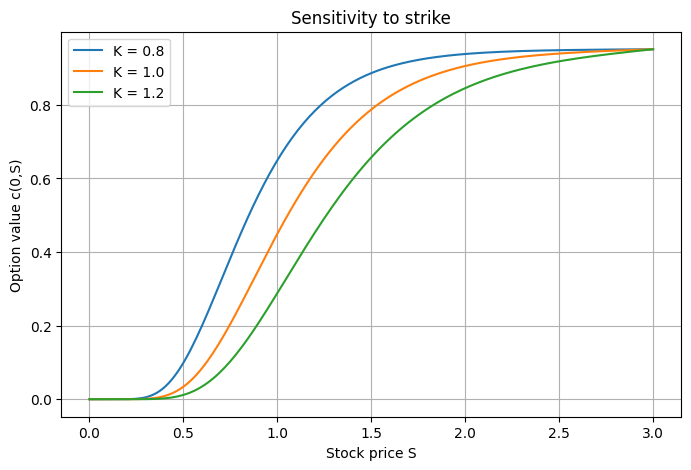

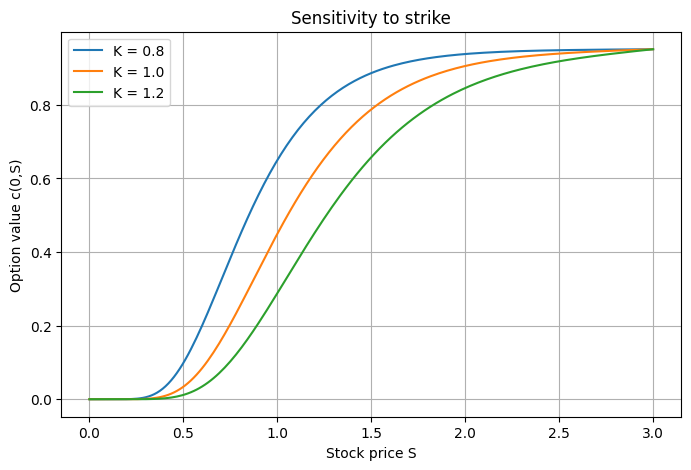

In [ ]:
Ks = [0.8, 1.0, 1.2]

plt.figure(figsize=(8,5))

for K_val in Ks:
    S, t, V = crank_nicolson_digital(K_val, r, sigma, T, S_max, M, N)
    plt.plot(S, V[:, 0], label=f"K = {K_val}")

plt.xlabel("Stock price S using Crank-Nicolson")
plt.ylabel("Option value c(0,S)")
plt.title("Sensitivity to strike")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))

for K_val in Ks:
    S, t, V = implicit_digital_call(K_val, r, sigma, T, S_max, M, N)
    plt.plot(S, V[:, 0], label=f"K = {K_val}")

plt.xlabel("Stock price S")
plt.ylabel("Option value c(0,S)")
plt.title("Sensitivity to strike using the implicit scheme")
plt.legend()
plt.grid(True)
plt.show()

We see a clear relation between the strike price and the option value for different stock prices.

We see that as the strike price increases the option loses value for allmost all stock prices. Only the stock prices that are far below the strike price stay zero. This is also what we would expect. A higher strike price is harder to reach, thus the plot shifts to the right, meaning that one needs a higher intial stock price to still have a similar chance of hitting the strike price.

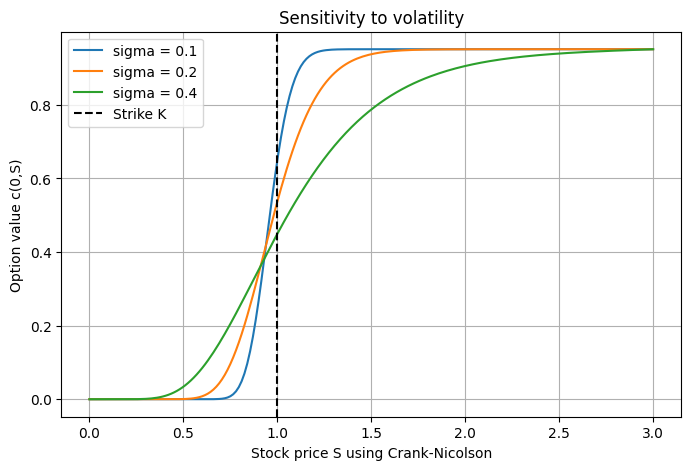

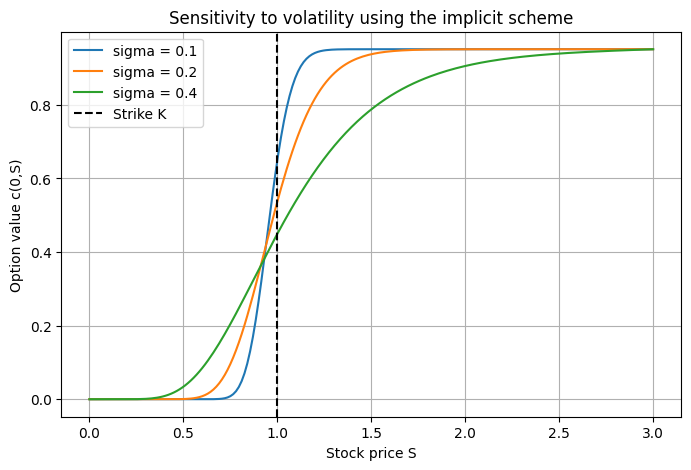

In [16]:
import matplotlib.pyplot as plt

sigmas = [0.1, 0.2, 0.4]

plt.figure(figsize=(8,5))

for sigma in sigmas:
    S, t, V = crank_nicolson_digital(K, r, sigma, T, S_max, M, N)
    plt.plot(S, V[:, 0], label=f"sigma = {sigma}")

plt.axvline(K, linestyle="--", color="black", label="Strike K")
plt.xlabel("Stock price S using Crank-Nicolson")
plt.ylabel("Option value c(0,S)")
plt.title("Sensitivity to volatility")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))

for sigma in sigmas:
    S, t, V = implicit_digital_call(K, r, sigma, T, S_max, M, N)
    plt.plot(S, V[:, 0], label=f"sigma = {sigma}")

plt.axvline(K, linestyle="--", color="black", label="Strike K")
plt.xlabel("Stock price S")
plt.ylabel("Option value c(0,S)")
plt.title("Sensitivity to volatility using the implicit scheme")
plt.legend()
plt.grid(True)
plt.show()

Here we see a bit of a different bevahiour, as we increase the sigma we see that the function becomes more gradual. We see that as the stock prices moves to the left of the strike price that the option value is potive correlated to sigma. This is due to the fact that stocks with a lower volatitly have a greater probability of falling below the strike price. While on the right of the strike price the opposite effect takes place.

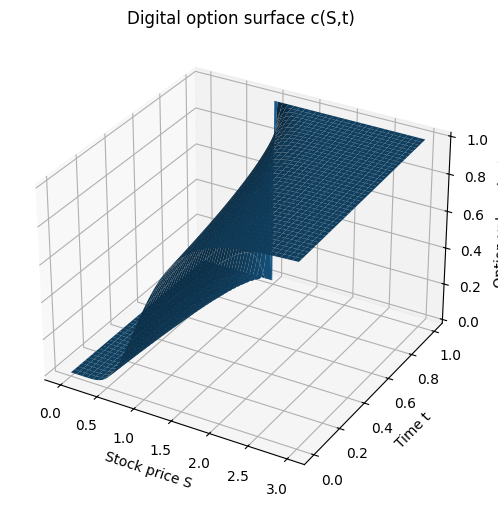

In [19]:
from mpl_toolkits.mplot3d import Axes3D

T_grid, S_grid = np.meshgrid(t, S)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(S_grid, T_grid, V, edgecolor='none')

ax.set_xlabel('Stock price S')
ax.set_ylabel('Time t')
ax.set_zlabel('Option value c(S,t)')
ax.set_title('Digital option surface c(S,t)')

plt.show()

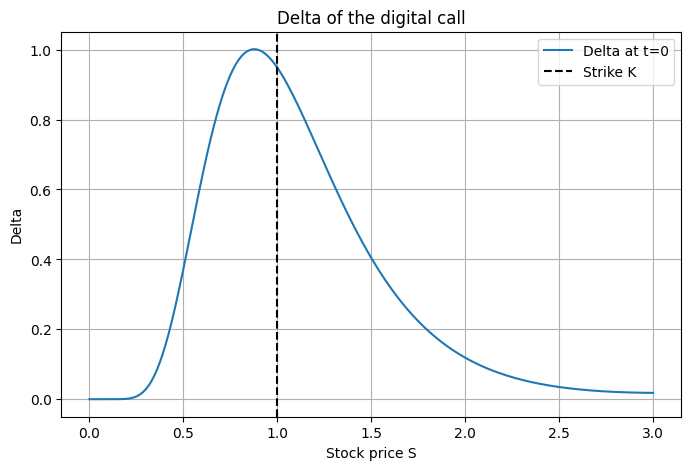

In [18]:
def compute_delta(V, S):
    dS = S[1] - S[0]
    delta = np.zeros_like(V)

    # interior points: central difference
    delta[1:-1, :] = (V[2:, :] - V[:-2, :]) / (2.0 * dS)

    # boundaries: one-sided difference
    delta[0, :] = (V[1, :] - V[0, :]) / dS
    delta[-1, :] = (V[-1, :] - V[-2, :]) / dS

    return delta

S, t, V = implicit_digital_call(K, r, sigma, T, S_max, M, N)
delta = compute_delta(V, S)

plt.figure(figsize=(8,5))
plt.plot(S, delta[:, 0], label="Delta at t=0")
plt.axvline(K, linestyle="--", color="black", label="Strike K")
plt.xlabel("Stock price S")
plt.ylabel("Delta")
plt.title("Delta of the digital call")
plt.legend()
plt.grid(True)
plt.show()

## Exercise 2
A quick disclaimer: the wording in this exercise is somewhat ambiguous.

The payoff is defined via formula as
$$
C = (S_T-K)^+ \mathbf{1}_{\{\max_{0\leq t\leq T} S_t < B\}}.
$$

In particular, the payoff is non-zero only if the barrier is never hit, i.e.
$$
\max_{0\leq t\leq T} S_t < B.
$$
Equivalently, the payoff is zero if and only if the barrier is reached at some time:
$$
\exists\, t \in [0,T] \text{ such that } S_t \ge B.
$$

However, the accompanying explanation states that the option is worthless if the barrier is not hit. So, there is a mismatch between the wording and the mathematical definition.

In this report we will be using the definition as described in the formula.


## Derivation
We will work with a knock-out barrier option. We will first derive the price when $K\leq B,$
$$
e^{-(T-t)r}1_{M^t_0<B}\mathbb{E}[(x\frac{S_{T-t}}{S_0}K)^+1\{x max_{0\leq u \leq T-t \frac{S_u}{S_0}<B}\}]_{x=S_t}
$$
The payoff for this kind of option would be:
$$
(S_T-K)^+1_{\{M_t^T<B\}},
$$
so at time t we have
$$
C(t) = e^{r(T-t)}\mathbb{E}[(S_T-K)^+1_{\{M_t^T<B\}}|\mathcal{F}_t],
$$
we split $1_{\{M_t^T<B\}} = 1_{\{M_0^t<B\}}1_{\{M_t^T<B\}}$

Now we use that
$
(S_T-K)^+ = 1_{\{S_T>K\}}(S_T-K),
$
which gives
$$
C(t) = 1_{\{M_0^t<B\}} e^{-r(T-t)}\mathbb{E}[(1_{\{S_T>K\}}S_T-K1_{\{S_T>K\}})1_{\{M_t^T<B\}}|\mathcal{F}_t]\\
=1_{\{M_0^t<B\}} e^{-r(T-t)}\mathbb{E}[1_{\{S_T>K\}}S_T1_{\{M_t^T<B\}}|\mathcal{F}_t]-K\mathbb{E}[1_{\{S_T>K\}}1_{\{M_t^T<B\}}|\mathcal{F}_t]
$$
We will denote $A:= \mathbb{E}[1_{\{S_T>K\}}S_T1_{\{M_t^T<B\}}|\mathcal{F}_t],$ and $C:= \mathbb{E}[1_{\{S_T>K\}}1_{\{M_t^T<B\}}|\mathcal{F}_t]$
Black-Scholes tells us that $S_{t+u} = S_t e^{(r-0.5\sigma^2)u+\sigma (B_{t+u-B_t})}.$

We will start with A,
$$
A =  \mathbb{E}[1_{\{S_T>K\}}S_T1_{\{M_t^T<B\}}|\mathcal{F}_t]
$$
for which
$$
 \mathbb{E}[1_{\{S_T>K\}}S_T|\mathcal{F}_t] = S_t\Phi(\delta_+^\tau(\frac{S_t}k))
$$
the reflected correction is given by
$$
 S_t\Phi(\delta_+^\tau(\frac{S_t}B))
$$
and lastly the image contribution is given by
$$
S_t(\frac B{S_t})^{1+2r/\sigma^2}[\Phi(\delta_+^\tau(\frac{B^2}{KS_t}))-\Phi(\delta_+^\tau(\frac{B}{S_t})).]
$$
and for our $C$ term, we have the same structure with:
$$
 S_t\Phi(\delta_-^\tau(\frac{S_t}k))
$$
the reflected correction is given by
$$
 S_t\Phi(\delta_-^\tau(\frac{S_t}B))
$$
and lastly the image contribution is given by
$$
S_t(\frac B{S_t})^{1-2r/\sigma^2}[\Phi(\delta_-^\tau(\frac{B^2}{KS_t}))-\Phi(\delta_-^\tau(\frac{B}{S_t})).]
$$
Putting all these pieces together yields the formula as stated in the exercise set.


In [39]:
def delta_pm(z, r, sigma, T, sign="+"):
    if sign == "+":
        return (np.log(z) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    else:
        return (np.log(z) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def up_and_out_call_closed_form(S0, K, B, r, sigma, T):
    # If already above barrier, knocked out
    if S0 >= B:
        return 0.0

    # If K > B, worthless for up-and-out call
    if K > B:
        return 0.0

    d1_SK = delta_pm(S0 / K, r, sigma, T, "+")
    d1_SB = delta_pm(S0 / B, r, sigma, T, "+")
    d1_B2KS = delta_pm(B**2 / (K * S0), r, sigma, T, "+")
    d1_BS = delta_pm(B / S0, r, sigma, T, "+")

    d2_SK = delta_pm(S0 / K, r, sigma, T, "-")
    d2_SB = delta_pm(S0 / B, r, sigma, T, "-")
    d2_B2KS = delta_pm(B**2 / (K * S0), r, sigma, T, "-")
    d2_BS = delta_pm(B / S0, r, sigma, T, "-")

    term1 = S0 * (norm.cdf(d1_SK) - norm.cdf(d1_SB))
    term2 = S0 * (B / S0)**(1 + 2 * r / sigma**2) * (norm.cdf(d1_B2KS) - norm.cdf(d1_BS))
    term3 = np.exp(-r * T) * K * (norm.cdf(d2_SK) - norm.cdf(d2_SB))
    term4 = (S0 / B)**(1 - 2 * r / sigma**2) * np.exp(-r * T) * K * (norm.cdf(d2_B2KS) - norm.cdf(d2_BS))

    return term1 - term2 - term3 + term4

In [40]:
def up_and_out_call_mc_adjusted(S0, K, B, r, sigma, T, N, m, beta1=0.5826):
    dt = T / m
    drift = (r - 0.5 * sigma**2) * dt
    vol = sigma * np.sqrt(dt)

    B_adj = B * np.exp(beta1 * sigma * np.sqrt(dt))

    # simulate log-returns
    Z = np.random.randn(N, m)
    log_increments = drift + vol * Z

    # build paths
    log_paths = np.cumsum(log_increments, axis=1)
    S_paths = S0 * np.exp(log_paths)

    # include initial value in barrier check
    S_full = np.concatenate([S0 * np.ones((N, 1)), S_paths], axis=1)

    # discrete barrier check with adjusted barrier
    alive = np.max(S_full, axis=1) < B_adj

    ST = S_paths[:, -1]
    payoffs = np.maximum(ST - K, 0.0) * alive

    discounted = np.exp(-r * T) * payoffs

    price = np.mean(discounted)
    std_error = np.std(discounted, ddof=1) / np.sqrt(N)

    return price, std_error, B_adj

In [41]:
S0 = 100
K = 100
B = 120
r = 0.05
sigma = 0.2
T = 1.0

analytic = up_and_out_call_closed_form(S0, K, B, r, sigma, T)
mc_price, mc_se, B_adj = up_and_out_call_mc_adjusted(S0, K, B, r, sigma, T,
                                                     N=100000, m=252)

print("Analytical price :", analytic)
print("MC adjusted price:", mc_price)
print("Std. error       :", mc_se)
print("Adjusted barrier :", B_adj)
print("Abs. error       :", abs(mc_price - analytic))

Analytical price : 1.176065399650362
MC adjusted price: 1.4972340935068065
Std. error       : 0.0116135156905309
Adjusted barrier : 120.88404892931435
Abs. error       : 0.3211686938564444


In [31]:
def implicit_up_and_out_call(S0, K, B, r, sigma, T, M, N):

    dS = B / M
    dt = T / N

    S = np.linspace(0.0, B, M + 1)
    t = np.linspace(0.0, T, N + 1)

    # V[i, n] = option value at stock level S[i], time t[n]
    V = np.zeros((M + 1, N + 1))

    # Terminal condition: payoff at maturity
    V[:, -1] = np.maximum(S - K, 0.0)

    # Boundary conditions
    V[0, :] = 0.0      # S = 0
    V[-1, :] = 0.0     # S = B barrier knock-out

    # Backward time stepping
    for n in range(N - 1, -1, -1):
        A = np.zeros((M - 1, M - 1))
        rhs = V[1:M, n + 1].copy()

        for i in range(1, M):
            Si = S[i]

            a = 0.5 * dt * (sigma**2 * Si**2 / dS**2 - r * Si / dS)
            b = 1.0 + dt * (sigma**2 * Si**2 / dS**2 + r)
            c = 0.5 * dt * (sigma**2 * Si**2 / dS**2 + r * Si / dS)

            row = i - 1

            if i > 1:
                A[row, row - 1] = -a
            A[row, row] = b
            if i < M - 1:
                A[row, row + 1] = -c

        # Boundary terms
        # Left boundary V[0, n] = 0, so no contribution
        # Right boundary V[M, n] = 0, so no contribution

        V[1:M, n] = np.linalg.solve(A, rhs)

    # Interpolate price at S0
    if S0 >= B:
        price = 0.0
    else:
        price = np.interp(S0, S, V[:, 0])

    return S, t, V, price



S0 = 100
K = 100
B = 130
r = 0.05
sigma = 0.2
T = 1.0
M = 200
N = 200

S, t, V, price = implicit_up_and_out_call(S0, K, B, r, sigma, T, M, N)
print("Implicit up-and-out call price:", price)

Implicit up-and-out call price: 3.336155827881889


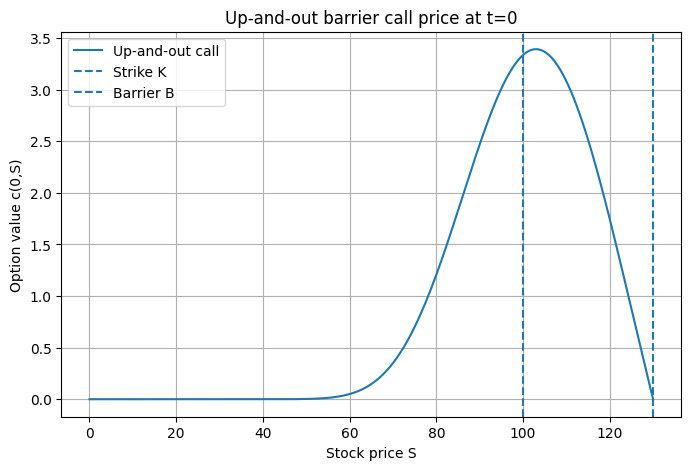

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(S, V[:, 0], label="Up-and-out call")
plt.axvline(K, linestyle="--", label="Strike K")
plt.axvline(B, linestyle="--", label="Barrier B")
plt.xlabel("Stock price S")
plt.ylabel("Option value c(0,S)")
plt.title("Up-and-out barrier call price at t=0")
plt.legend()
plt.grid(True)
plt.show()

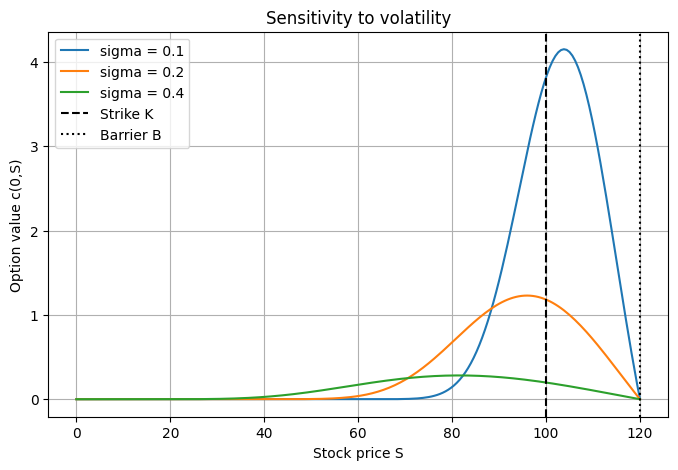

In [42]:
sigmas = [0.1, 0.2, 0.4]

plt.figure(figsize=(8, 5))
for sig in sigmas:
    S, t, V_tmp, _ = implicit_up_and_out_call(S0, K, B, r, sig, T, M, N)
    plt.plot(S, V_tmp[:, 0], label=f"sigma = {sig}")

plt.axvline(K, linestyle="--", color="black", label="Strike K")
plt.axvline(B, linestyle=":", color="black", label="Barrier B")
plt.xlabel("Stock price S")
plt.ylabel("Option value c(0,S)")
plt.title("Sensitivity to volatility")
plt.legend()
plt.grid(True)
plt.show()

We see that the curve flattens as we assume higher volatility. From which we can conclude that higher volatility reduces the options value. This is due to the fact that a higher volatility means that the chances of hitting a boundary is higher. At the same time we see the curve move to the left. Which means that at lower stock prices the option holds more value. This is due to the fact that a higher volatility increases the chance of hitting the strike price.

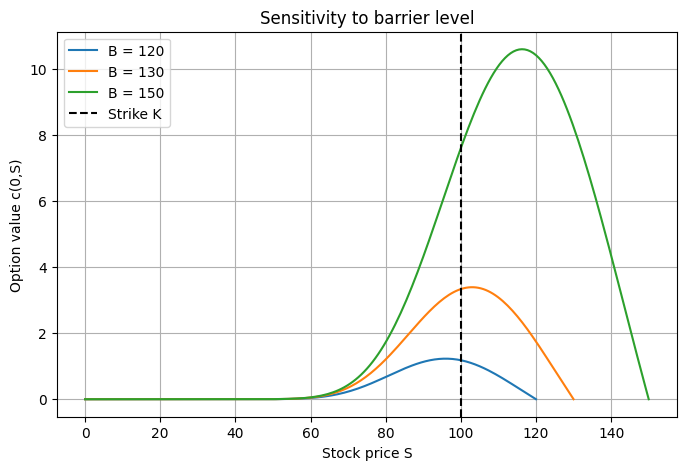

In [34]:
barriers = [120, 130, 150]

plt.figure(figsize=(8, 5))
for Bb in barriers:
    S_tmp, t_tmp, V_tmp, _ = implicit_up_and_out_call(S0, K, Bb, r, sigma, T, M, N)
    plt.plot(S_tmp, V_tmp[:, 0], label=f"B = {Bb}")

plt.axvline(K, linestyle="--", color="black", label="Strike K")
plt.xlabel("Stock price S")
plt.ylabel("Option value c(0,S)")
plt.title("Sensitivity to barrier level")
plt.legend()
plt.grid(True)
plt.show()

We clearly see that increasing the barrier increases the options value. Again this is unsurprinsing. Increasing the barrier value, would mean the option would have a higher chance of being non-zero.

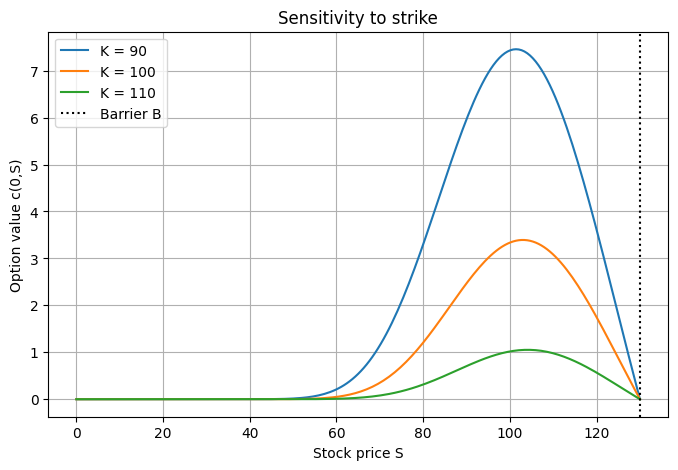

In [35]:
Ks = [90, 100, 110]

plt.figure(figsize=(8, 5))
for Kk in Ks:
    S_tmp, t_tmp, V_tmp, _ = implicit_up_and_out_call(S0, Kk, B, r, sigma, T, M, N)
    plt.plot(S_tmp, V_tmp[:, 0], label=f"K = {Kk}")

plt.axvline(B, linestyle=":", color="black", label="Barrier B")
plt.xlabel("Stock price S")
plt.ylabel("Option value c(0,S)")
plt.title("Sensitivity to strike")
plt.legend()
plt.grid(True)
plt.show()

We clearly see that as the strike price increases the value of the option decreases. We see that they all follow the same shape. Zero for lower stock prices, then an increase around the strike price, and dropping back to zero as the stock price reaches the barrier.

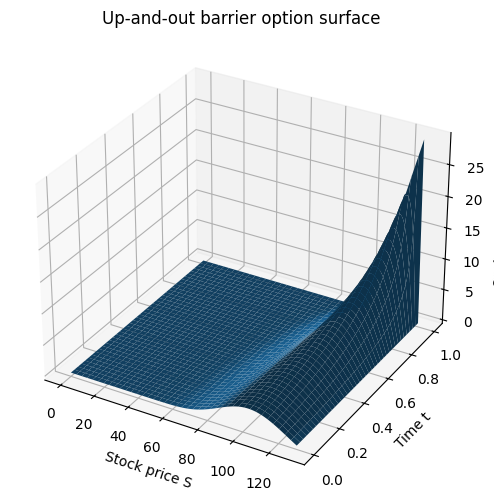

In [36]:
T_grid, S_grid = np.meshgrid(t, S)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S_grid, T_grid, V, edgecolor='none')

ax.set_xlabel("Stock price S")
ax.set_ylabel("Time t")
ax.set_zlabel("Option value c(S,t)")
ax.set_title("Up-and-out barrier option surface")
plt.show()

In [37]:
def compute_delta(V, S):
    dS = S[1] - S[0]
    delta = np.zeros_like(V)

    # central difference for interior points
    delta[1:-1, :] = (V[2:, :] - V[:-2, :]) / (2.0 * dS)

    # one-sided differences at boundaries
    delta[0, :] = (V[1, :] - V[0, :]) / dS
    delta[-1, :] = (V[-1, :] - V[-2, :]) / dS

    return delta

delta = compute_delta(V, S)

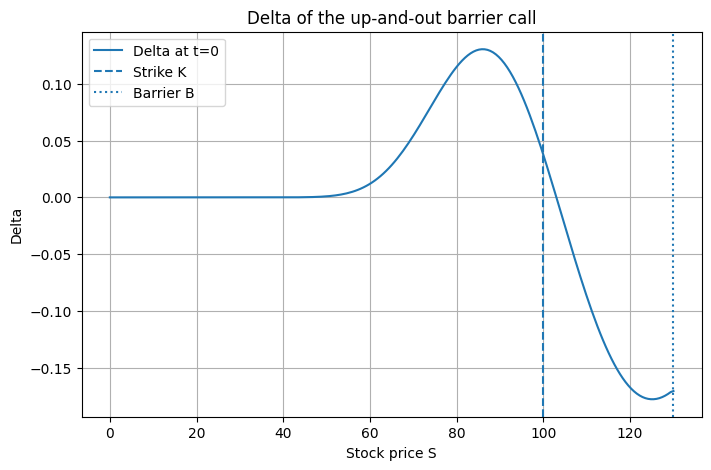

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(S, delta[:, 0], label="Delta at t=0")
plt.axvline(K, linestyle="--", label="Strike K")
plt.axvline(B, linestyle=":", label="Barrier B")
plt.xlabel("Stock price S")
plt.ylabel("Delta")
plt.title("Delta of the up-and-out barrier call")
plt.legend()
plt.grid(True)
plt.show()